In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from google.colab.patches import cv2_imshow # For displaying images in Colab

To detect faces, we'll use a pre-trained Haar Cascade classifier provided by OpenCV. First, let's download the XML file for the frontal face cascade.

In [2]:
# Download the Haar Cascade XML file for frontal face detection
!wget https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml -O haarcascade_frontalface_default.xml

--2026-03-06 10:36:06--  https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 930127 (908K) [text/plain]
Saving to: ‘haarcascade_frontalface_default.xml’

haarcascade_frontal 100%[===================>] 908.33K  --.-KB/s    in 0.04s   

2026-03-06 10:36:06 (25.1 MB/s) - ‘haarcascade_frontalface_default.xml’ saved [930127/930127]



Now, let's load the classifier and an example image. If you have your own image, you can upload it to your Colab environment or provide its URL.

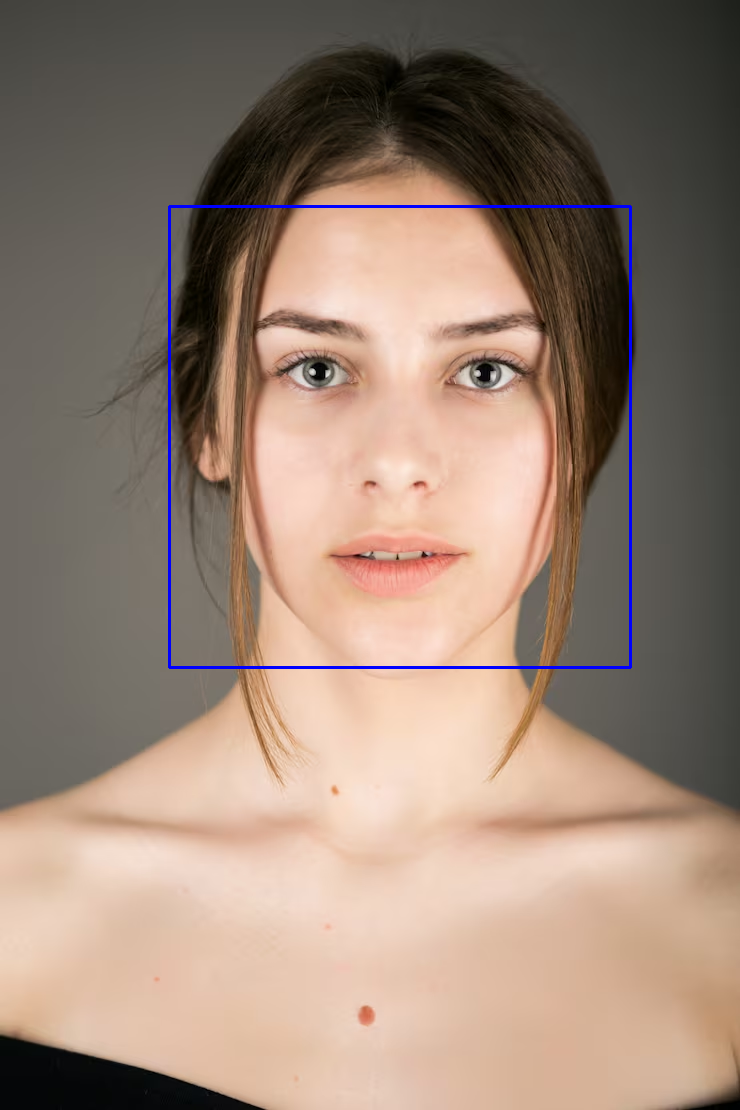

Detected 1 face(s).


In [3]:
# Load the Haar Cascade classifier
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

# Check if the cascade classifier loaded successfully
if face_cascade.empty():
    raise IOError('Unable to load the face cascade classifier XML file. Make sure it exists and the path is correct.')

# Load the image provided by the user
image_path = '/content/face image.avif'
image = cv2.imread(image_path)

# Check if the image loaded successfully
if image is None:
    raise IOError(f'Unable to load image from {image_path}. Please ensure the file exists and is in a format OpenCV can read. You might need to convert .avif to .jpg or .png if it fails.')

# Convert the image to grayscale, as face detection works better on grayscale images
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Perform face detection
# detectMultiScale(image, scaleFactor, minNeighbors)
# scaleFactor: Parameter specifying how much the image size is reduced at each image scale.
# minNeighbors: Parameter specifying how many neighbors each candidate rectangle should have to retain it.
faces = face_cascade.detectMultiScale(gray_image, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

# Draw rectangles around the detected faces
for (x, y, w, h) in faces:
    cv2.rectangle(image, (x, y), (x+w, y+h), (255, 0, 0), 2) # Draw a blue rectangle with thickness 2

# Display the result
cv2_imshow(image)
print(f"Detected {len(faces)} face(s).")